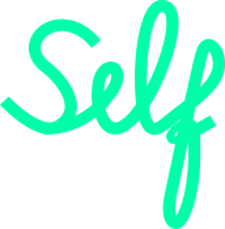

# Simulador de gasto diario tipo Starbucks

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [10]:
def formato_clp(x, pos):
    return f"${x:,.0f}".replace(",", ".")

In [11]:
valor_cafe=2500
compra_cafe_siempre=True
probabilidad_cafe=0.8
dias_por_mes=22
meses=12
random_seed=42

## Simulación sólo café

In [12]:
np.random.seed(random_seed)
rows=[]
for m in range(1,meses+1):
    for d in range(1,dias_por_mes+1):
        total=0
        cafe=compra_cafe_siempre or np.random.rand()<probabilidad_cafe
        if cafe: total+=valor_cafe

        rows.append({"mes":m,"dia":d,"cafe":cafe,"gasto":total})
df=pd.DataFrame(rows)
mensual=df.groupby("mes")["gasto"].sum()
print(df.head())
print("Gasto anual:",mensual.sum())

   mes  dia  cafe  gasto
0    1    1  True   2500
1    1    2  True   2500
2    1    3  True   2500
3    1    4  True   2500
4    1    5  True   2500
Gasto anual: 660000


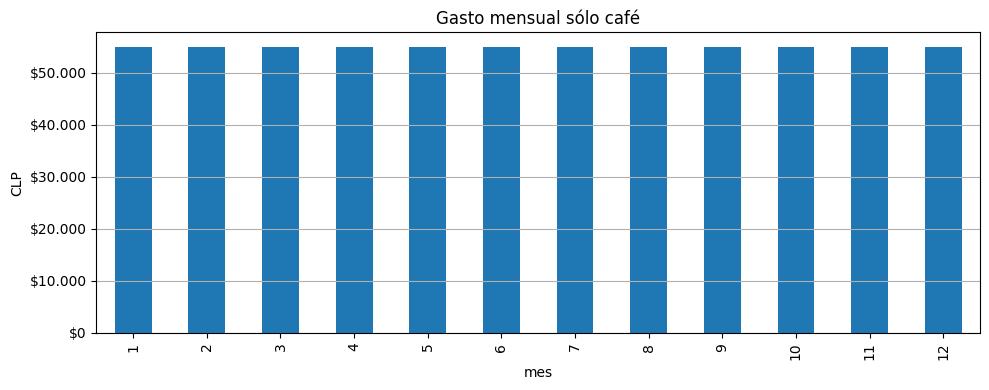

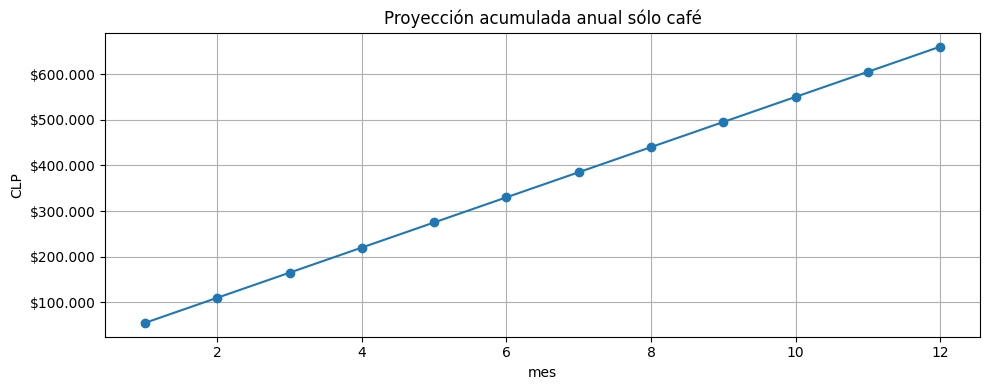

In [13]:
from matplotlib.ticker import FuncFormatter

# Gráfico 1
fig, ax = plt.subplots(figsize=(10, 4))

mensual.plot(kind="bar", ax=ax)

ax.set_title("Gasto mensual sólo café")
ax.set_ylabel("CLP")
ax.yaxis.set_major_formatter(FuncFormatter(formato_clp))
ax.grid(axis="y")

plt.tight_layout()
plt.show()


# Gráfico 2
fig, ax = plt.subplots(figsize=(10, 4))

mensual.cumsum().plot(marker="o", ax=ax)

ax.set_title("Proyección acumulada anual sólo café")
ax.set_ylabel("CLP")
ax.yaxis.set_major_formatter(FuncFormatter(formato_clp))
ax.grid(True)

plt.tight_layout()
plt.show()

## Simulación con acompañamientos

In [14]:
extras={
    "Medialuna":(1500,0.2),
    "Cookie":(1800,0.12),
    "Muffin":(2600,0.08),
    "Brownie":(2500,0.06),
    "Agua":(1800,0.05),
    "Jugo":(2900,0.04),
    "Sandwich":(5900,0.03),
}
np.random.seed(random_seed)
rows=[]
for m in range(1,meses+1):
    for d in range(1,dias_por_mes+1):
        total=0
        cafe=compra_cafe_siempre or np.random.rand()<probabilidad_cafe
        if cafe: total+=valor_cafe
        ex={}
        for k,(v,p) in extras.items():
            b=np.random.rand()<p
            ex[k]=b
            if b: total+=v
        rows.append({"mes":m,"dia":d,"cafe":cafe,"gasto":total}|ex)
df=pd.DataFrame(rows)
mensual=df.groupby("mes")["gasto"].sum()
print(df.head())
print("Gasto anual:",mensual.sum())

   mes  dia  cafe  gasto  Medialuna  Cookie  Muffin  Brownie   Agua   Jugo  \
0    1    1  True   2500      False   False   False    False  False  False   
1    1    2  True   5000      False   False   False     True  False  False   
2    1    3  True   4000       True   False   False    False  False  False   
3    1    4  True   4000       True   False   False    False  False  False   
4    1    5  True   4300      False    True   False    False  False  False   

   Sandwich  
0     False  
1     False  
2     False  
3     False  
4     False  
Gasto anual: 1015600


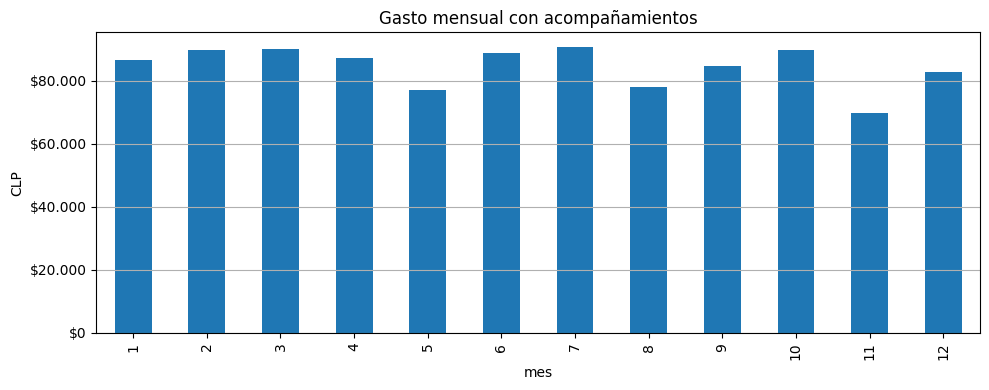

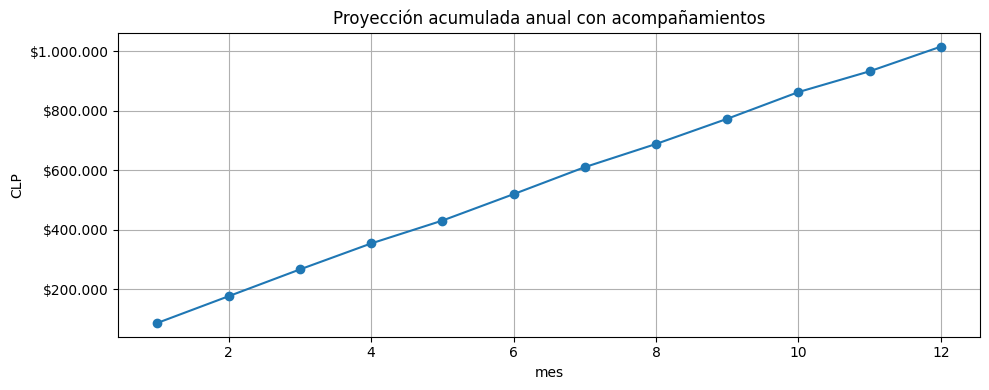

In [15]:
from matplotlib.ticker import FuncFormatter

# Gráfico 1
fig, ax = plt.subplots(figsize=(10, 4))

mensual.plot(kind="bar", ax=ax)

ax.set_title("Gasto mensual con acompañamientos")
ax.set_ylabel("CLP")
ax.yaxis.set_major_formatter(FuncFormatter(formato_clp))
ax.grid(axis="y")

plt.tight_layout()
plt.show()


# Gráfico 2
fig, ax = plt.subplots(figsize=(10, 4))

mensual.cumsum().plot(marker="o", ax=ax)

ax.set_title("Proyección acumulada anual con acompañamientos")
ax.set_ylabel("CLP")
ax.yaxis.set_major_formatter(FuncFormatter(formato_clp))
ax.grid(True)

plt.tight_layout()
plt.show()